#🤑 Mall Customers Segmentation with O-Cluster

##About Dataset

The Mall Customers Dataset provides data on 200 individuals who visit a mall, including demographic information, annual income, and spending habits. This dataset is useful for exploratory data analysis, customer segmentation, and clustering tasks (e.g., K-means clustering).

##Dataset summary
 * Rows : 200
 * Columns : 5  
 * No missing values

##Columns Description
 * CustomerID : A unique identifier for each customer (integer) .
 * Genre : The gender of the customer (Male/Famale) .
 * Age : The age of the customer (integer) .
 * Annual Income (k$) : Annual income of the customer in thousands of dollars (integer) .
 * Spending Score (1-100) : A score assigned by the mall based on customer behavior and spending patterns (integer).

##Problem we want to solve

Create clusters representing types of clients based on their Annual Income and Spending Score.



In [1]:
! pip install -q kaggle

In [2]:
import os

os.makedirs("/root/.kaggle", exist_ok=True)
!cp drive/MyDrive/Colab\ Notebooks/Kaggle/kaggle.json /root/.kaggle/
!chmod 600 /root/.kaggle/kaggle.json

In [3]:
!kaggle datasets download -d abdallahwagih/mall-customers-segmentation

Dataset URL: https://www.kaggle.com/datasets/abdallahwagih/mall-customers-segmentation
License(s): apache-2.0
  0% 0.00/1.56k [00:00<?, ?B/s]
100% 1.56k/1.56k [00:00<00:00, 6.31MB/s]


In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
# Unzip the uploaded data into Google Drive
!unzip -q mall-customers-segmentation.zip

In [6]:
import pandas as pd
import random

customers_data = pd.read_csv("/content/mall-customers-segmentation.zip")
customers_data = customers_data.sample(frac=1).reset_index(drop=True)
customers_data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,118,Female,49,65,59
1,124,Male,39,69,91
2,20,Female,35,23,98
3,14,Female,24,20,77
4,102,Female,49,62,48


In [7]:
#Information about dataset
customers_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Genre                   200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [8]:
# Check for null values
customers_data.isnull().sum()

,0
CustomerID,0
Genre,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


In [9]:
import numpy as np
# Change Gerne in bool values
unique_labels = np.unique(customers_data["Genre"])
customers_data["Genre"] = [genre == unique_labels for genre in customers_data["Genre"]]

In [10]:
# Change Genre in numeric values
customers_data["Genre"] = [np.argmax(genre) for genre in customers_data["Genre"]]
customers_data.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,118,0,49,65,59
1,124,1,39,69,91
2,20,0,35,23,98
3,14,0,24,20,77
4,102,0,49,62,48


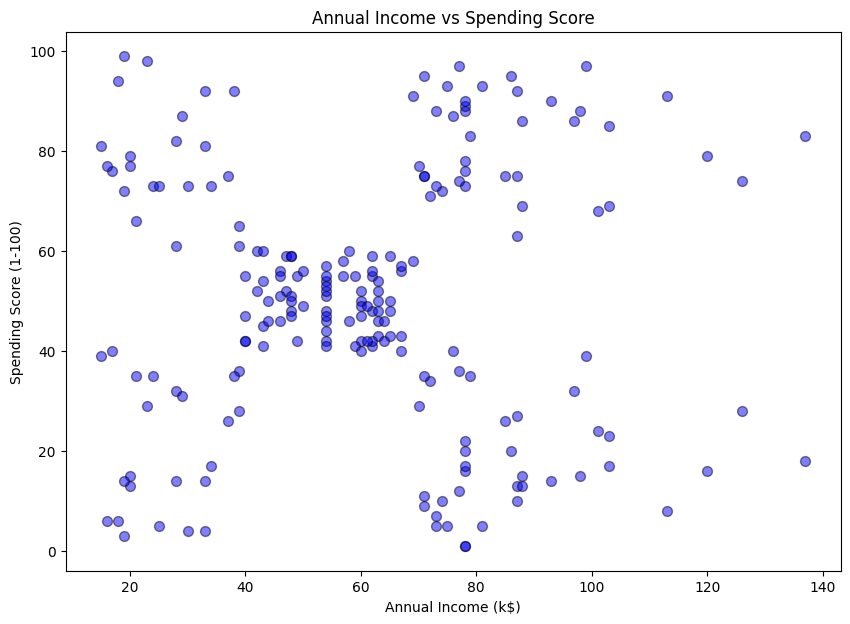

In [11]:
# Plot Annual Income and Spending score
import matplotlib.pyplot as plt

plt.figure(figsize=(10,7))
plt.scatter(customers_data['Annual Income (k$)'] , customers_data['Spending Score (1-100)'], s=50 , c='blue' , alpha=0.5 , edgecolors='k')
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")
plt.title("Annual Income vs Spending Score")
plt.show()

In [12]:
import numpy as np
from collections import defaultdict
# O_Cluster algorithm

class OCluster:
  # Constructor of the class
  def __init__(self , grid_resolution=10 , density_threshold=0.2):
      self.grid_resolution = grid_resolution
      self.density_threshold = density_threshold
      self.labels_ = None

  def _get_cell_index(self , point):
          # Map a normalized point to a grid cell index
          # Example : [0.35 , 0.72] with resolution 10 -> (3,7)
          return tuple((point * self.grid_resolution).astype(int).clip(0,self.grid_resolution - 1))

  def _get_neighbors(self, cell):
        # Get all neighboring cells
        neighbors = []
        dims = len(cell)

        # Loop over all offset combinations
        for offset in np.ndindex(*(3,) * dims): # -1 , 0 , 1 | each axis
            if all(o == 1 for o in offset):
                continue # skip the cell itself
            neighbor = tuple(np.array(cell) + np.array(offset) - 1)
            # Only include neighbors that are within the grid bounds
            if all(0 <= n < self.grid_resolution for n in neighbor):
                neighbors.append(neighbor)
        return neighbors


  def _build_density_grid(self,X):
          # Assign each point to its corresponding grid cell
          cell_points = defaultdict(list)
          for i , point in enumerate(X):
             cell = self._get_cell_index(point)
             cell_points[cell].append(i)
          total_points = len(X)
          # Calculate density = number of points in cell / total number of points
          density_grid = {cell : len(indices) / total_points for cell , indices in cell_points.items()}

          return density_grid , cell_points

  def fit(self , X):
          # Fit the O-Cluster algorithm on data X
          density_grid , cell_points = self._build_density_grid(X) # Build grid with densities
          visited = set() # Track visited dence cells
          labels = np.full(len(X) , -1) # Initialize all labels to -1 (noise)
          cluster_id = 0 # Start cluster ID counter

          # Loop over each cell in the density grid
          for cell in density_grid:
              # Start cluster from dense and unvisited cells
              if density_grid[cell] >= self.density_threshold and cell not in visited:
                  queue = [cell] # Start BFS queue
                  visited.add(cell)
                  current_cluster_points = [] # Store all point indices in this cluster

                  # Expand cluster by visiting all dense neighbors (BFS-style)
                  while queue:
                      current = queue.pop()
                      current_cluster_points.extend(cell_points[current])

                      for neighbor in self._get_neighbors(current):
                          if neighbor in density_grid and density_grid[neighbor] >= self.density_threshold and neighbor not in visited:
                              visited.add(neighbor)
                              queue.append(neighbor)

                  # Assign the same cluster ID to all points in the cluster
                  for idx in current_cluster_points:
                      labels[idx] = cluster_id
                  # Increment for next cluster
                  cluster_id += 1

          # Store final cluster labels
          self.labels_ = labels
          return self

In [18]:
# Implement O-Cluster
X = customers_data[['Annual Income (k$)' , 'Spending Score (1-100)']].values

# Normalize all data from dataset
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X = scaler.fit_transform(X)

oc = OCluster(grid_resolution=20 , density_threshold=0.005)
fit_oc = oc.fit(X)
labels = oc.labels_

In [14]:
customers_data = customers_data[['Annual Income (k$)' , 'Spending Score (1-100)']]
customers_data['Cluster'] = labels
customers_data.head()

/tmp/ipython-input-14-1020924860.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  customers_data['Cluster'] = labels


,Annual Income (k$),Spending Score (1-100),Cluster
0,65,59,0
1,69,91,1
2,23,98,0
3,20,77,0
4,62,48,0


In [15]:
cluster_stats = customers_data.groupby('Cluster').mean()
print(cluster_stats.round())

         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                      54.0                    46.0
1                      81.0                    83.0
2                      22.0                     8.0
3                      32.0                    15.0
4                     102.0                    68.0
5                     137.0                    83.0
6                      98.0                    36.0
7                     123.0                    76.0
8                     113.0                    91.0
9                     137.0                    18.0
10                    126.0                    28.0
11                    113.0                     8.0
12                    120.0                    16.0


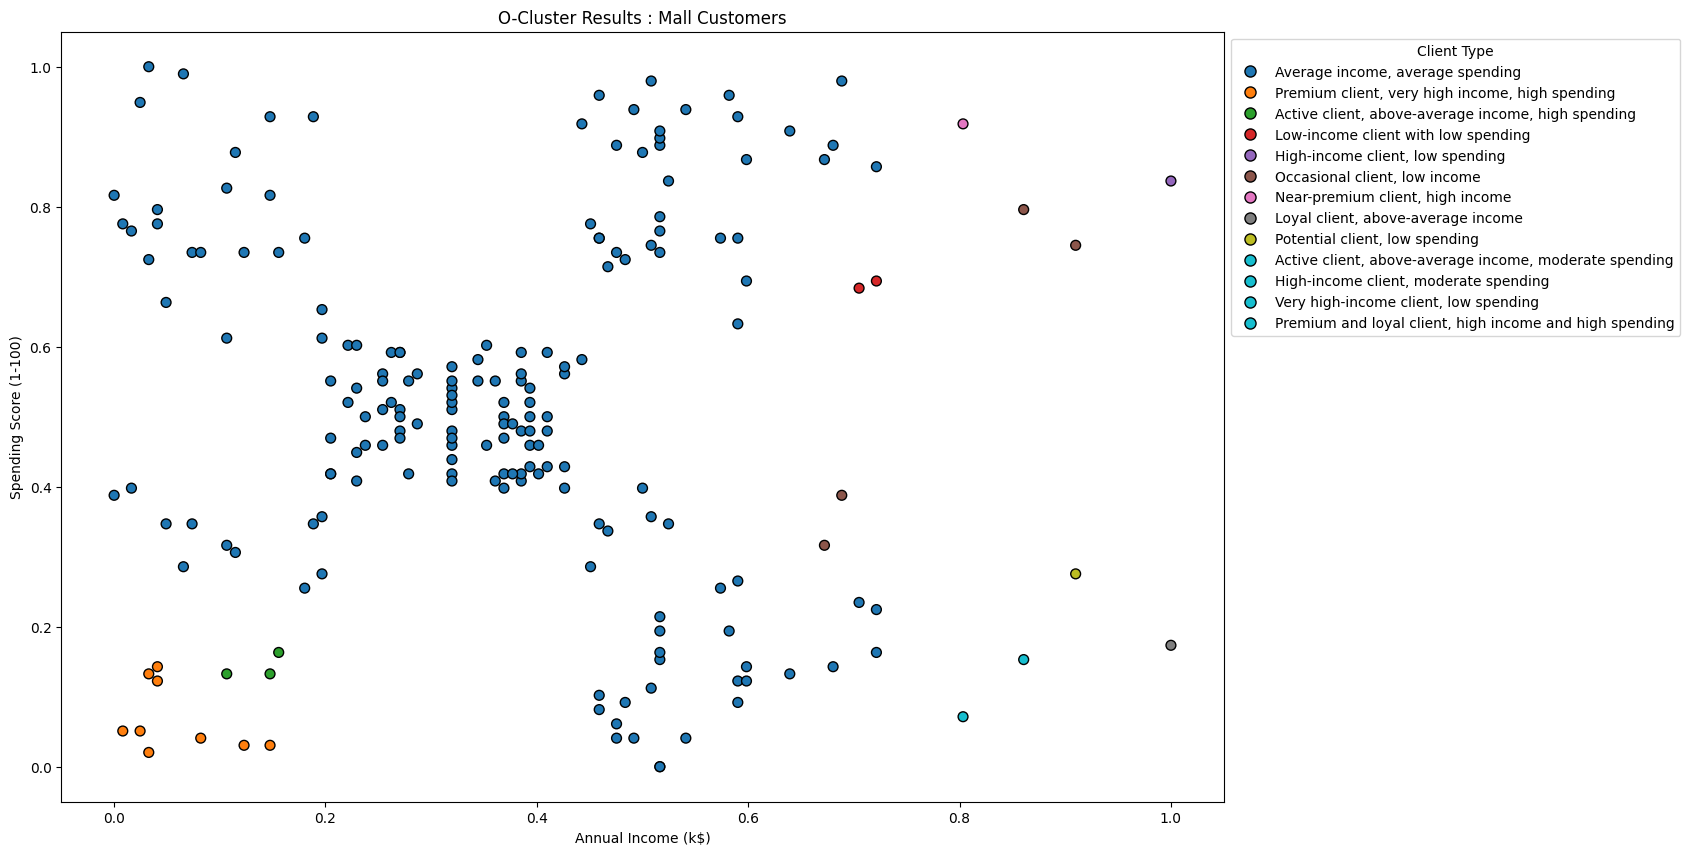

In [16]:
# Intrerpretation for each cluster
labels_dict = {
    0: 'Average income, average spending',
    1: 'Premium client, very high income, high spending',
    2: 'Active client, above-average income, high spending',
    3: 'Low-income client with low spending',
    4: 'High-income client, low spending',
    5: 'Occasional client, low income',
    6: 'Near-premium client, high income',
    7: 'Loyal client, above-average income',
    8: 'Potential client, low spending',
    9: 'Active client, above-average income, moderate spending',
    10: 'High-income client, moderate spending',
    11: 'Very high-income client, low spending',
    12: 'Premium and loyal client, high income and high spending'
}

# Color for each cluster
colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan', 'magenta', 'yellow', 'teal']

plt.figure(figsize=(15,10))
plt.scatter(X[:,0] , X[:,1] , c=labels , s=50 , cmap='tab10' , edgecolor='k')
plt.title("O-Cluster Results : Mall Customers")
plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

handles = []
for cluster_id, label in labels_dict.items():
    color = plt.cm.tab10(cluster_id / 10)
    handles.append(plt.Line2D([], [], marker='o', color=color, linestyle='',
                              markersize=8, label=label, markeredgecolor='k'))

plt.legend(handles=handles, title="Client Type" , loc="upper left", bbox_to_anchor=(1, 1))
plt.show()

In [17]:
labels

array([ 0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  2,  0,  1,  0,  0,  3,  0,
        1,  0,  0,  0,  0,  1,  1,  0,  4,  0,  0,  1,  0,  0,  0,  0,  0,
        0,  0,  1,  5,  0,  0,  0,  0,  1,  0,  0,  0,  0,  1,  1,  2,  0,
        0,  0,  0,  0,  2,  0,  0,  0,  0,  0,  6,  0,  0,  1,  0,  0,  0,
        0,  0,  3,  0,  1,  0,  0,  0,  0,  1,  0,  0,  7,  0,  3,  0,  0,
        0,  0,  7,  0,  2,  0,  0,  0,  0,  0,  0,  1,  0,  8,  1,  1,  0,
        1,  0,  0,  0,  1,  9,  0,  0,  0,  0,  0,  0,  1,  1,  0,  1,  0,
        1,  0,  4,  2,  1,  0,  0,  0,  0,  0,  0,  0,  2,  0,  0,  1,  1,
        0,  0,  1,  0,  0,  1,  0,  0,  1,  0, 10,  0,  1, 11,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  6,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  2,  1,  0,  0,  0,  1,  0,  0,  0,  0,  0,  0,  0,
        2,  0,  1,  0,  1,  0,  2, 12,  0,  0,  0,  0,  0])